# Connecting Kaggle json

# GETTING THE DATASET AND Unzipping the files

In [4]:
!mkdir -p ~/.kaggle/
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Getting the DataSet

In [5]:
!kaggle datasets download -d samuelcortinhas/sports-balls-multiclass-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification
License(s): CC0-1.0
 85% 342M/401M [00:00<00:00, 645MB/s]
100% 401M/401M [00:00<00:00, 545MB/s]


## Unzipping the data

In [6]:
!unzip /content/sports-balls-multiclass-image-classification.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/cricket_ball/cricket_ball_182.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_183.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_185.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_186.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_187.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_189.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_19.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_190.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_191.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_192.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_195.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_196.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_199.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_200.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_

# Importing Packages

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Rescaling

import tensorflow as tf
import os


# For reproducibility
import numpy as np
import random
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

seed = 123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

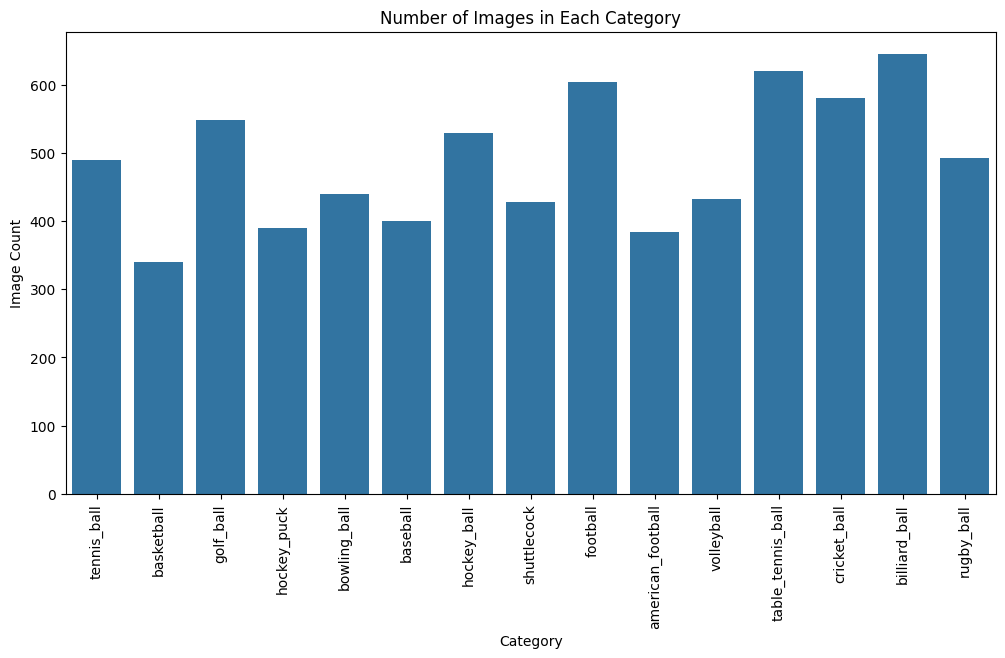

In [8]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Directory path (update with the correct path to your 'train' directory)
train_dir = '/content/train'

# Dictionary to store subdirectory names and file counts
data = {'Category': [], 'Image Count': []}

# Loop through each subdirectory
for sub_dir in os.listdir(train_dir):
    sub_dir_path = os.path.join(train_dir, sub_dir)
    if os.path.isdir(sub_dir_path):
        # Count the number of files (images) in the subdirectory
        num_files = len([f for f in os.listdir(sub_dir_path) if os.path.isfile(os.path.join(sub_dir_path, f))])
        data['Category'].append(sub_dir)
        data['Image Count'].append(num_files)

# Convert the data to a pandas DataFrame
df = pd.DataFrame(data)

# Create the bar plot using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Image Count', data=df)
plt.xticks(rotation=90)
plt.title('Number of Images in Each Category')
plt.ylabel('Image Count')
plt.xlabel('Category')
plt.show()

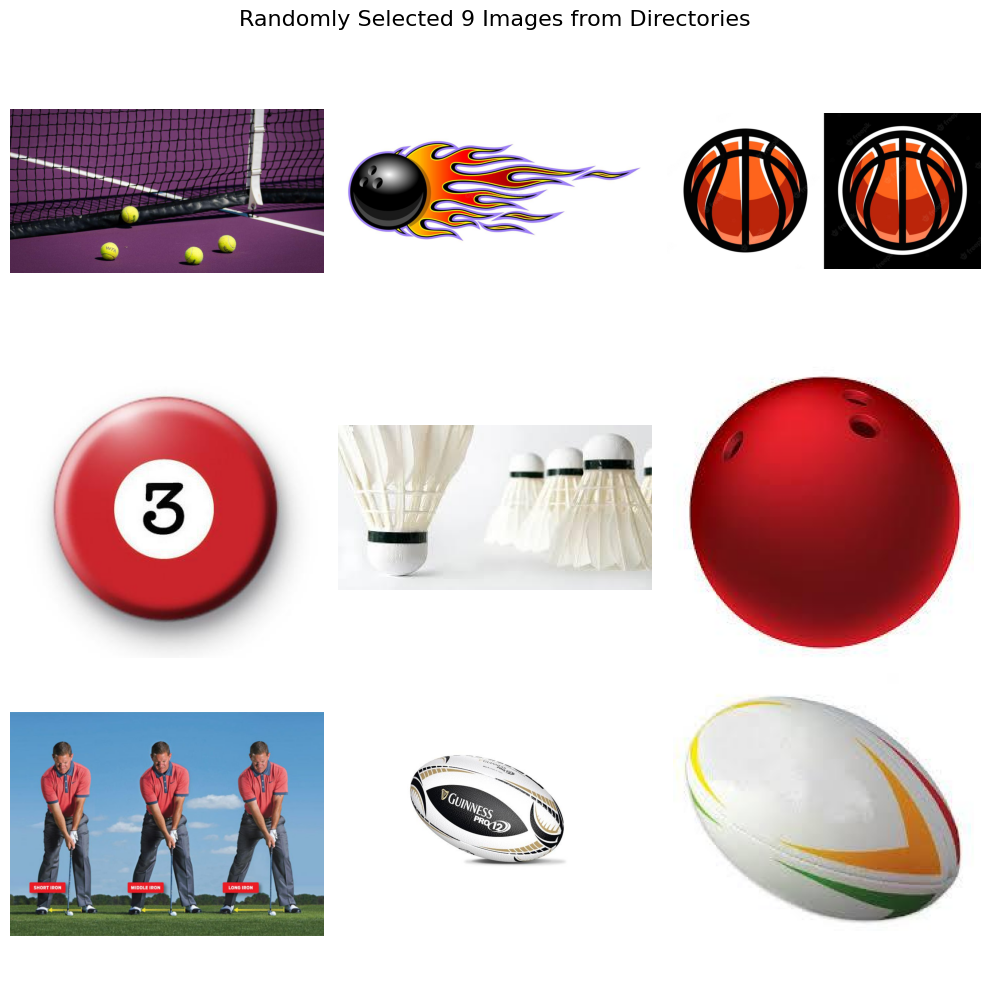

In [9]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory path (update with the correct path to your 'train' directory)
train_dir = '/content/train'

# Get all subdirectories and files in the directories
all_images = []
for sub_dir in os.listdir(train_dir):
    sub_dir_path = os.path.join(train_dir, sub_dir)
    if os.path.isdir(sub_dir_path):
        all_images.extend([os.path.join(sub_dir_path, f) for f in os.listdir(sub_dir_path) if os.path.isfile(os.path.join(sub_dir_path, f))])

# Randomly select 9 images
random_images = random.sample(all_images, 9)

# Plotting the images in a 3x3 grid
plt.figure(figsize=(10, 10))
for i, image_path in enumerate(random_images):
    img = mpimg.imread(image_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis('off')  # Turn off the axis

plt.suptitle('Randomly Selected 9 Images from Directories', fontsize=16)
plt.tight_layout()
plt.show()


# Data Preparation

In [10]:
# Set up directory and parameters
train_dir = '/content/train'
img_size = (224, 224)         # ResNet50 standard input size
batch_size = 32               # Adjust batch size as per your GPU capacity

In [11]:
# Data Augmentation layers (applied during training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),  # Random horizontal flip
    layers.RandomRotation(0.1),  # Random rotation
    layers.RandomZoom(0.1),  # Random zoom
])

# Flow from direcotory.

In [12]:
# Load training and validation datasets using image_dataset_from_directory
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = 'inferred',
    label_mode = 'categorical',
    validation_split=0.2,  # 80/20 split for training/validation
    subset="training",
    seed=123,  # For reproducibility
    image_size=img_size,
    batch_size=batch_size
)

Found 7328 files belonging to 15 classes.
Using 5863 files for training.


In [13]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    labels = 'inferred',
    label_mode = 'categorical',
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 7328 files belonging to 15 classes.
Using 1465 files for validation.


In [14]:
# Apply data augmentation only to the training data
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

In [15]:
# Optional: Prefetch data for performance improvement
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Model Buidling

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(15, activation='softmax')) # Assuming 15 classes based on the dataset

model.summary()

In [17]:
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    # First 1x1 Convolution to reduce dimensions
    x = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Second 3x3 Convolution
    x = layers.Conv2D(filters, kernel_size=kernel_size, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Third 1x1 Convolution to restore dimensions
    x = layers.Conv2D(filters * 4, kernel_size=1, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Shortcut connection (adjust dimensions if necessary)
    if stride != 1 or shortcut.shape[-1] != filters * 4:
        shortcut = layers.Conv2D(filters * 4, kernel_size=1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add the shortcut
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [18]:
def build_resnet50(input_shape=(224, 224, 3), num_classes=15):
    inputs = tf.keras.Input(shape=input_shape)

    # x = layers.rescaling(1/255.)
    # Initial Convolution and MaxPooling
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Residual Blocks (Bottleneck Architecture)
    x = residual_block(x, filters=64)
    x = residual_block(x, filters=64)
    x = residual_block(x, filters=64)

    x = residual_block(x, filters=128, stride=2)
    x = residual_block(x, filters=128)
    x = residual_block(x, filters=128)
    x = residual_block(x, filters=128)

    x = residual_block(x, filters=256, stride=2)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)
    x = residual_block(x, filters=256)

    x = residual_block(x, filters=512, stride=2)
    x = residual_block(x, filters=512)
    x = residual_block(x, filters=512)

    # Global Average Pooling and Output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, x)
    return model

In [19]:
# Build the model
model = build_resnet50(input_shape=(224, 224, 3))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     16,640 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     16,640 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ add[0][0]       

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 23,565,327 (89.89 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [20]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5  # Adjust epochs as needed
)

# Pretrained model and fine tuning

In [22]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Set up directory and parameters
train_dir = '/content/train'
img_size = (224, 224)
batch_size = 32
num_classes = 15  # Update this with the actual number of classes in your dataset

# Load the pre-trained ResNet50 model excluding the top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) # Pretrained on imagedataset

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [24]:
# Freeze the base model layers
base_model.trainable = False

# Create a new model on top of the pre-trained base model
inputs = tf.keras.Input(shape=(224, 224, 3))

# Normalization layer
x = layers.Rescaling(1./255)(inputs)

# Optional: Apply augmentation (if augmentation is needed)
# x = layers.RandomFlip('horizontal')(x)
# x = layers.RandomRotation(0.1)(x)
# x = layers.RandomZoom(0.1)(x)

# Pass the inputs through the pre-trained ResNet50 base model
x = base_model(x, training=False)

# Global average pooling to reduce the output to a single vector per image
x = layers.GlobalAveragePooling2D()(x)

# Add a fully connected layer with the number of classes
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)  # Dropout to reduce overfitting

# Final output layer with softmax activation for classification
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build the model
model = models.Model(inputs, outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,116,111 (92.00 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [26]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Load training and validation datasets using image_dataset_from_directory
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Prefetch data for performance improvement
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Train the new layers while keeping the base model frozen
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20  # Adjust epochs as needed
)

Found 7328 files belonging to 15 classes.
Using 5863 files for training.
Found 7328 files belonging to 15 classes.
Using 1465 files for validation.
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.1441 - loss: 2.5667 - val_accuracy: 0.1454 - val_loss: 2.5493
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.1532 - loss: 2.5556 - val_accuracy: 0.1659 - val_loss: 2.5337
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.1537 - loss: 2.5466 - val_accuracy: 0.1727 - val_loss: 2.5124
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.1620 - loss: 2.5373 - val_accuracy: 0.1829 - val_loss: 2.4854
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.1675 - loss: 2.5121 - val_accuracy: 0.2068 - val_loss: 2.5054
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.1682 - loss: 2.4981 - val_accuracy: 0.1884 - val_loss: 2.4713
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy:

# Layers fine tuning

In [27]:
# Load the pre-trained ResNet50 model excluding the top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) # Pretrained on imagedataset

# Unfreeze the last few layers of the base model for fine-tuning
base_model.trainable = True

# Let's set up how many layers we want to fine-tune
# For example, we can choose to fine-tune the last 10 layers of the base model
fine_tune_at = 140  # Unfreeze from this layer onwards

# Freeze all layers before `fine_tune_at`
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [28]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,172,911 (96.03 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,056,800 (4.03 MB)

In [29]:

# Compile the model again after unfreezing layers (lower learning rate for fine-tuning)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Lower learning rate for fine-tuning
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model
fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5  # Increase epochs for fine-tuning
)


Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 77s 168ms/step - accuracy: 0.2095 - loss: 2.3659 - val_accuracy: 0.2498 - val_loss: 2.3548
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.2123 - loss: 2.3507 - val_accuracy: 0.2505 - val_loss: 2.3426
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.2226 - loss: 2.3237 - val_accuracy: 0.2478 - val_loss: 2.3356
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.2353 - loss: 2.3267 - val_accuracy: 0.2505 - val_loss: 2.3316
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.2279 - loss: 2.3341 - val_accuracy: 0.2485 - val_loss: 2.3292


# Assignment



*   Complete this code to train for larger epochs
*   Do the performnce plots and evaulation and confusion matrix
*   Do the whole thing for the inception model

